# Comecando a Analise Exploratoria

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

# Paleta: vermelho dos graficos de municipio + fundo branco
COR_VERMELHO = "#FF2A00"


def estilo_eixos_barra(ax, grid_axis="y"):
    """Eixos limpos (sem moldura superior/direita) e grade discreta."""
    ax.set_facecolor("#FFFFFF")
    sns.despine(ax=ax, top=True, right=True, offset=2)
    ax.grid(
        axis=grid_axis,
        linestyle=":",
        linewidth=0.85,
        alpha=0.55,
        color="#C8C8C8",
    )
    ax.set_axisbelow(True)

In [3]:
df = pd.read_csv("csvs/feminicidios_2022_2025.csv", encoding="utf-8-sig")
df.head()

,ANO_BO,ANO_ESTATISTICA,BAIRRO,DATA_OCORRENCIA_BO,DESCR_CONDUTA,DESC_PERIODO,HORA_OCORRENCIA_BO,LATITUDE,LOGRADOURO,LONGITUDE,...,NOME_DELEGACIA_CIRCUNSCRICAO,NOME_DEPARTAMENTO,NOME_DEPARTAMENTO_CIRCUNSCRICAO,NOME_MUNICIPIO,NOME_MUNICIPIO_CIRCUNSCRICAO,NOME_SECCIONAL,NOME_SECCIONAL_CIRCUNSCRICAO,NUMERO_LOGRADOURO,NUM_BO,RUBRICA
0,2022.0,2022.0,PARQUE FERNANDA,22/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,20:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,47º D.P. CAPAO REDONDO,DECAP,DECAP,S.PAULO,S.PAULO,DEL.SEC.6º SANTO AMARO,DEL.SEC.6º SANTO AMARO,NaN,AE2379,Homicídio (art. 121)
1,2022.0,2022.0,BELVEDERE,12/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,20:10:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,DEL.POL.PENÁPOLIS,DEINTER 10 - ARAÇATUBA,DEINTER 10 - ARAÇATUBA,PENAPOLIS,PENAPOLIS,DEL.SEC.ARACATUBA,DEL.SEC.ARACATUBA,NaN,AC0317,Homicídio (art. 121)
2,2022.0,2022.0,AREA RURAL,12/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,19:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,01º D.P. GUARUJA,DEINTER 6 - SANTOS,DEINTER 6 - SANTOS,GUARUJA,GUARUJA,DEL.SEC.SANTOS,DEL.SEC.SANTOS,NaN,AC4630,Homicídio (art. 121)
3,2022.0,2022.0,PARQUE IMPERIAL,09/01/2022,Feminicídio-contra a mulher por razões da cond...,NaN,21:00:00,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,02º D.P. BARUERI,DEMACRO,DEMACRO,BARUERI,BARUERI,DEL.SEC.CARAPICUIBA,DEL.SEC.CARAPICUIBA,NaN,AB3503,Homicídio (art. 121)
4,2022.0,2022.0,JD ESPERANÇA,24/01/2022,Feminicídio-contra a mulher por razões da cond...,EM HORA INCERTA,NaN,0,VEDAÇÃO DA DIVULGAÇÃO DOS DADOS RELATIVOS,0,...,DEL.POL.BARUERI,DEMACRO,DEMACRO,BARUERI,BARUERI,DEL.SEC.CARAPICUIBA,DEL.SEC.CARAPICUIBA,NaN,AF1638,Homicídio (art. 121)


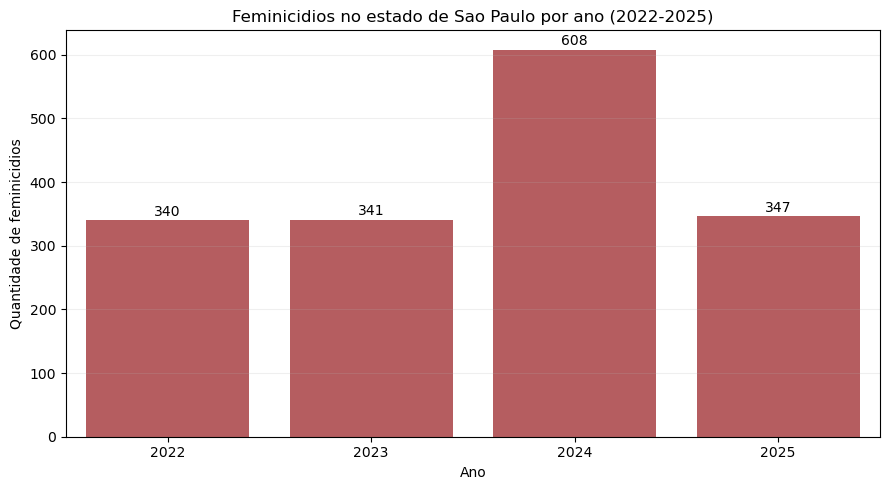

,ANO_ESTATISTICA,QTD_FEMINICIDIOS
0,2022,340
1,2023,341
2,2024,608
3,2025,347


In [5]:
feminicidios_por_ano = (
    df.assign(ANO_ESTATISTICA=df["ANO_ESTATISTICA"].astype("Int64"))
      .groupby("ANO_ESTATISTICA", dropna=True)
      .size()
      .reset_index(name="QTD_FEMINICIDIOS")
      .sort_values("ANO_ESTATISTICA")
)

fig, ax = plt.subplots(figsize=(9, 5), facecolor="#FFFFFF")
sns.barplot(
    data=feminicidios_por_ano,
    x="ANO_ESTATISTICA",
    y="QTD_FEMINICIDIOS",
    color=COR_VERMELHO,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="y")
ax.set_title(
    "Feminicidios no estado de Sao Paulo por ano (2022-2025)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Ano", fontsize=11, color="#333333")
ax.set_ylabel("Quantidade de feminicidios", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

ymax = feminicidios_por_ano["QTD_FEMINICIDIOS"].max()
pad = max(8, ymax * 0.04)
for i, valor in enumerate(feminicidios_por_ano["QTD_FEMINICIDIOS"]):
    ax.text(
        i,
        valor + pad,
        f"{int(valor)}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#3a3a3a",
    )
ax.set_ylim(0, ymax + pad * 2.2)

plt.tight_layout()
plt.show()

feminicidios_por_ano

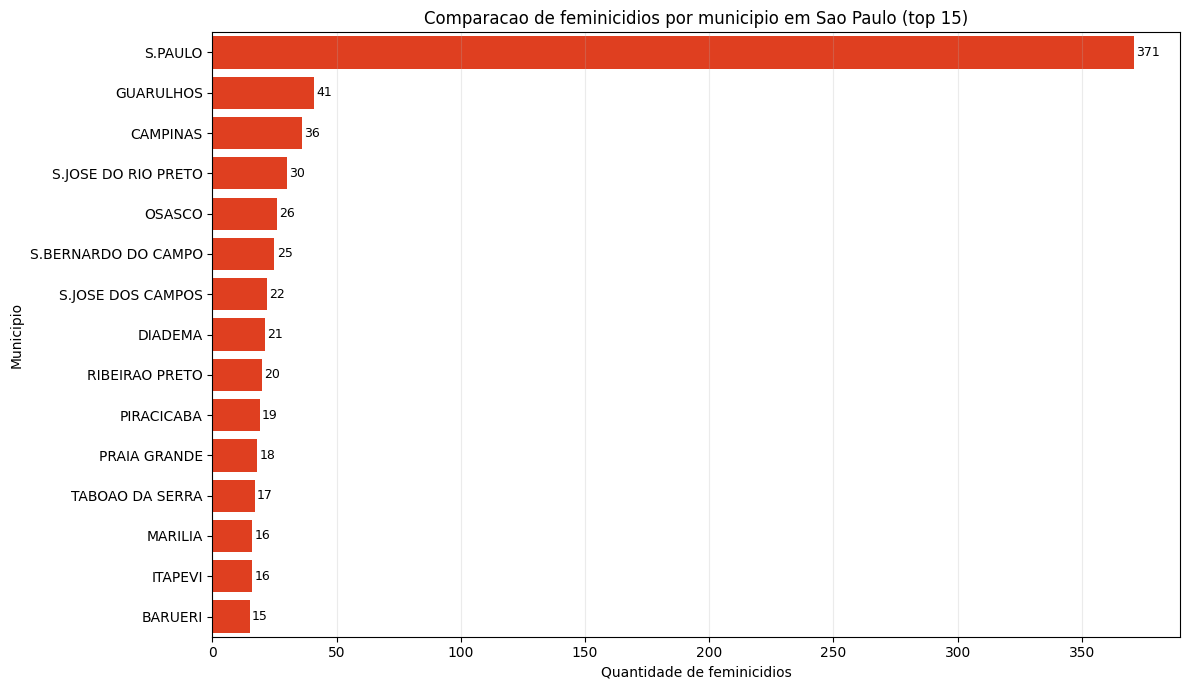

,NOME_MUNICIPIO,QTD_FEMINICIDIOS
284,S.PAULO,371
117,GUARULHOS,41
58,CAMPINAS,36
278,S.JOSE DO RIO PRETO,30
211,OSASCO,26
265,S.BERNARDO DO CAMPO,25
279,S.JOSE DOS CAMPOS,22
84,DIADEMA,21
254,RIBEIRAO PRETO,20
233,PIRACICABA,19


In [13]:
feminicidios_por_municipio = (
    df.dropna(subset=["NOME_MUNICIPIO"])
      .assign(NOME_MUNICIPIO=df["NOME_MUNICIPIO"].astype(str).str.strip())
      .groupby("NOME_MUNICIPIO")
      .size()
      .reset_index(name="QTD_FEMINICIDIOS")
      .sort_values("QTD_FEMINICIDIOS", ascending=False)
)

top_municipios = feminicidios_por_municipio.head(15)

fig, ax = plt.subplots(figsize=(12, 7), facecolor="#FFFFFF")
sns.barplot(
    data=top_municipios,
    y="NOME_MUNICIPIO",
    x="QTD_FEMINICIDIOS",
    color=COR_VERMELHO,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="x")
ax.set_title(
    "Comparacao de feminicidios por municipio em Sao Paulo (top 15)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Quantidade de feminicidios", fontsize=11, color="#333333")
ax.set_ylabel("Municipio", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

xpad = max(1.5, top_municipios["QTD_FEMINICIDIOS"].max() * 0.02)
for index, value in enumerate(top_municipios["QTD_FEMINICIDIOS"]):
    ax.text(value + xpad, index, f"{int(value)}", va="center", fontsize=9, color="#3a3a3a")

plt.tight_layout()
plt.show()

top_municipios

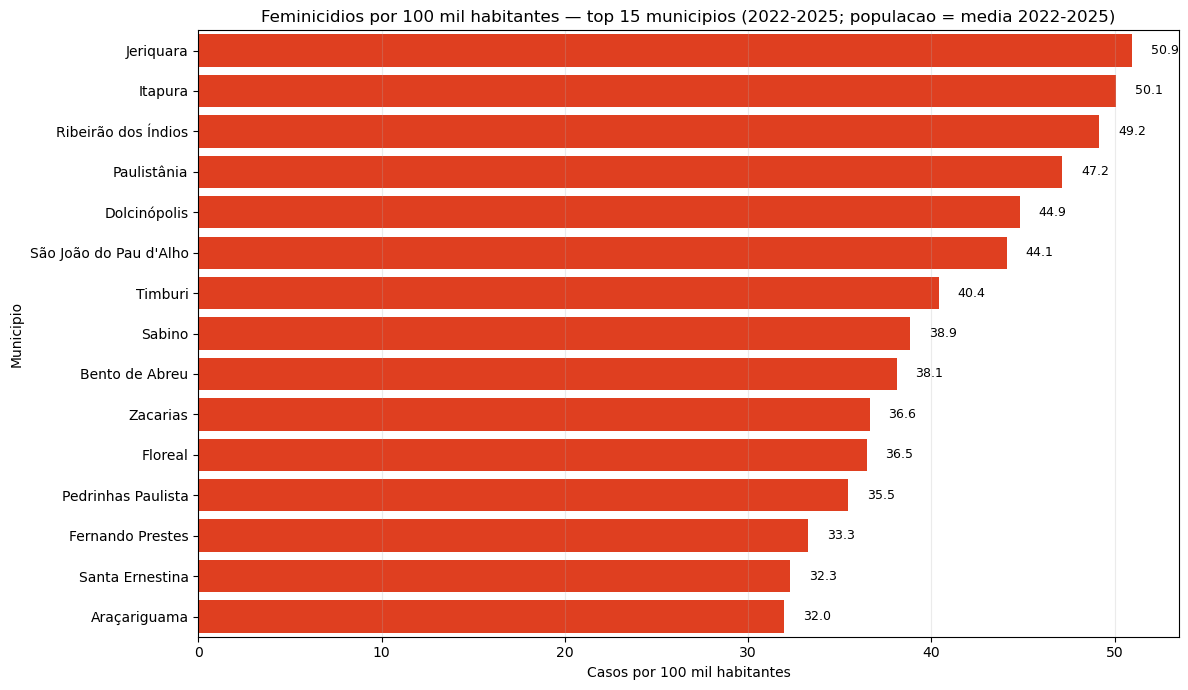

,municipio_chave,QTD_FEMINICIDIOS,id_municipio,municipio,populacao_media_2022_2025,taxa_100k_hab
168,JERIQUARA,2,3525409,Jeriquara,3925.50,50.948924
151,ITAPURA,2,3523008,Itapura,3993.50,50.081382
252,RIBEIRAO DOS INDIOS,1,3543238,Ribeirão dos Índios,2033.75,49.170252
223,PAULISTANIA,1,3536570,Paulistânia,2120.50,47.158689
87,DOLCINOPOLIS,1,3514205,Dolcinópolis,2229.50,44.853106
285,SAO JOAO DO PAU DALHO,1,3549300,São João do Pau d'Alho,2266.25,44.125758
318,TIMBURI,1,3554607,Timburi,2475.50,40.395880
259,SABINO,2,3544608,Sabino,5147.75,38.851926
35,BENTO DE ABREU,1,3506201,Bento de Abreu,2623.50,38.117019
333,ZACARIAS,1,3557154,Zacarias,2729.50,36.636747


In [9]:
from municipio_sp import chave_nome_bo

pop_mean = pd.read_csv("csvs/populacao_municipio_SP_media_2022_2025.csv")

df_fem = (
    df.dropna(subset=["NOME_MUNICIPIO"])
    .assign(municipio_chave=lambda d: d["NOME_MUNICIPIO"].astype(str).str.strip().map(chave_nome_bo))
)
por_chave = (
    df_fem.groupby("municipio_chave", dropna=False)
    .size()
    .reset_index(name="QTD_FEMINICIDIOS")
)
norm_mun = por_chave.merge(pop_mean, on="municipio_chave", how="left")
norm_mun["taxa_100k_hab"] = (
    norm_mun["QTD_FEMINICIDIOS"] / norm_mun["populacao_media_2022_2025"] * 100_000
)

sem_pop = norm_mun["populacao_media_2022_2025"].isna()
if sem_pop.any():
    print("Aviso: sem população para as chaves:", norm_mun.loc[sem_pop, "municipio_chave"].tolist())

norm_ok = norm_mun.dropna(subset=["populacao_media_2022_2025"])
top15_taxa = norm_ok.nlargest(15, "taxa_100k_hab")

fig, ax = plt.subplots(figsize=(12, 7), facecolor="#FFFFFF")
sns.barplot(
    data=top15_taxa,
    y="municipio",
    x="taxa_100k_hab",
    color=COR_VERMELHO,
    ax=ax,
)
estilo_eixos_barra(ax, grid_axis="x")
ax.set_title(
    "Feminicidios por 100 mil habitantes — top 15 municipios "
    "(2022-2025; populacao = media 2022-2025)",
    fontsize=13,
    fontweight="semibold",
    color="#1a1a1a",
    pad=14,
)
ax.set_xlabel("Casos por 100 mil habitantes", fontsize=11, color="#333333")
ax.set_ylabel("Municipio", fontsize=11, color="#333333")
ax.tick_params(axis="both", colors="#444444")

xpad = max(top15_taxa["taxa_100k_hab"]) * 0.02
for index, value in enumerate(top15_taxa["taxa_100k_hab"]):
    ax.text(value + xpad, index, f"{value:.1f}", va="center", fontsize=9, color="#3a3a3a")

plt.tight_layout()
plt.show()

top15_taxa

In [11]:
jan_2023 = (
    df.assign(
        ANO_ESTATISTICA=df["ANO_ESTATISTICA"].astype("Int64"),
        MES_ESTATISTICA=df["MES_ESTATISTICA"].astype("Int64")
    )
    .query("ANO_ESTATISTICA == 2023 and MES_ESTATISTICA == 1")
    .shape[0]
)

print(f"Feminicidios em janeiro de 2023: {jan_2023}")
jan_2023

Feminicidios em janeiro de 2023: 16


/var/folders/99/91w1yg4n471bh9d24fb6ln440000gn/T/ipykernel_46113/812316618.py:6: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  .query("ANO_ESTATISTICA == 2023 and MES_ESTATISTICA == 1")


16